# AG-HYPOPT · Trial 01

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

[Trial 01, campaign start. The registry (trials.json) is empty: no previous trials exist, so there is no current-best reference. This is the first trial of experiment_3_pukky and the optimizer is in its uniform-design phase (0/5 completed), so cell 2 samples 10 candidates uniformly across the space (sigma_ref 5-25, lr_mu 5-30, lr_gamma 0.2-1.0, gamma_anneal 0-0.75). Context from context.md: the frozen pipeline is the 17f optimizer (fixed sigma_ref normalization, z-form gamma-score, LAMBDA_MEAN=0), and the objective is the combined relative MSE of (mu, gamma) over the 8-experiment benchmark (Trans05/20/60/100 at 1nW and 3nW, 100x10 budget). Known failure modes to keep in mind while reading later trials: optimizer starvation at high mu, low-count gamma noise at Trans05, and the high-transmission model gap. Here there is simply nothing to exploit yet.]


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_01'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 20    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = uniform  (0/5 trials)
ID |     ei | params
 1 |      - | {"gamma_anneal": 0.38386621852519254, "lr_gamma": 0.9603709570607484, "lr_mu": 8.603990317990844, "sigma_ref": 23.972988942744877}
 2 |      - | {"gamma_anneal": 0.2338735890078641, "lr_gamma": 0.5386611591780606, "lr_mu": 25.692564845511043, "sigma_ref": 13.183982727383226}
 3 |      - | {"gamma_anneal": 0.4121952657547946, "lr_gamma": 0.22204729059445472, "lr_mu": 23.837827716870166, "sigma_ref": 15.762866264385565}
 4 |      - | {"gamma_anneal": 0.24729878737431912, "lr_gamma": 0.8307429627427234, "lr_mu": 12.579870732291123, "sigma_ref": 14.06995778961303}
 5 |      - | {"gamma_anneal": 0.10053127293537356, "lr_gamma": 0.5224903891577034, "lr_mu": 10.08638101690374, "sigma_ref": 10.24626680883699}
 6 |      - | {"gamma_anneal": 0.5627735044725395, "lr_gamma": 0.424327006388832, "lr_mu": 17.129774360790876, "sigma_ref": 24.61474399602477}
 7 |      - | {"gamma_anneal": 0.72124289524784, "lr_gamma": 0.7798319526188269, 

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

[First trial, uniform phase, empty registry: there is no history to exploit, so this is a coverage decision - pick a sensible starting point. The defaults the pipeline was validated with are sigma_ref=10, lr_mu=15, lr_gamma=0.5, gamma_anneal=0.5 (DEFAULT_CONFIG). Candidate 5 (sigma_ref 10.25, lr_mu 10.09, lr_gamma 0.52, gamma_anneal 0.10) sits almost exactly on that validated sigma_ref/lr_gamma baseline while giving a milder mu learning rate and much less gamma annealing, so it is the most sensible anchor for the very first objective and a good reference for the trials that follow. The alternatives are more extreme (candidate 1: sigma_ref 24 with lr_mu 8.6 probes the strong-normalization end; candidate 3: lr_gamma 0.22 probes a weak gamma LR) and are better saved for later exploration. I choose candidate 5.]


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 5               # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.10053127293537356, 'lr_gamma': 0.5224903891577034, 'lr_mu': 10.08638101690374, 'sigma_ref': 10.24626680883699}
Running  1nW Trans05 ... 

μ 9.39 -> 5.04 | γ 8.5 -> 7.09 | NLL 1.45


Running  1nW Trans20 ... 

μ 17.32 -> 10.43 | γ 8.5 -> 10.07 | NLL 3.27


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 66.50 | γ 14.1 -> 15.09 | NLL 4.65


Running 3nW Trans100 ... 

μ 175.71 -> 107.22 | γ 14.1 -> 14.58 | NLL 4.25



Total: 6.5 min


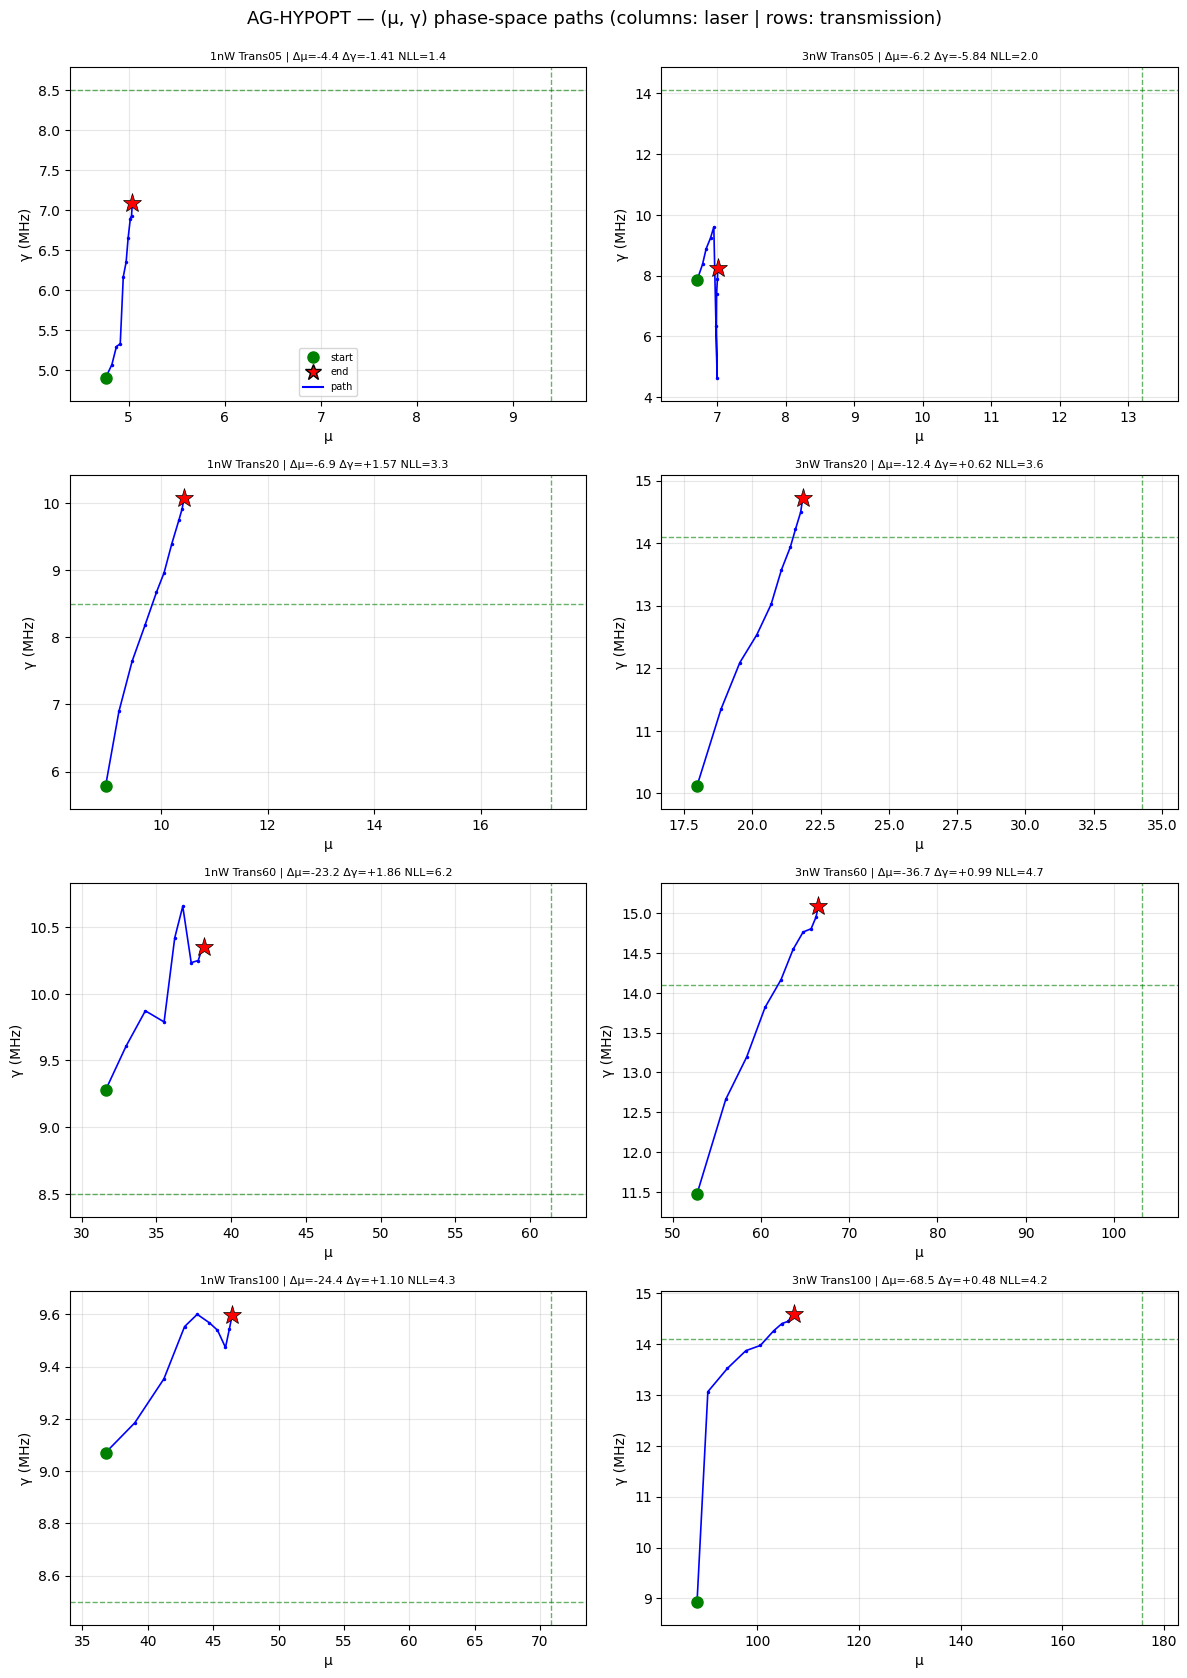

trial finished in 6.5 min
objective = 0.0981 ± 0.0194
exp           μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05     9.39    5.04   -46.4 |     8.50    7.09   -16.6
1nW Trans20    17.32   10.43   -39.8 |     8.50   10.07   +18.5
1nW Trans60    61.37   38.19   -37.8 |     8.50   10.36   +21.8
1nW Trans100   70.82   46.46   -34.4 |     8.50    9.60   +12.9
3nW Trans05    13.20    7.01   -46.9 |    14.10    8.26   -41.4
3nW Trans20    34.28   21.84   -36.3 |    14.10   14.72    +4.4
3nW Trans60   103.20   66.50   -35.6 |    14.10   15.09    +7.0
3nW Trans100  175.71  107.22   -39.0 |    14.10   14.58    +3.4

μ: RMSE 30.471 (rel 39.8%, bias -22.825) | γ: RMSE 2.365 (rel 19.5%, bias -0.079)


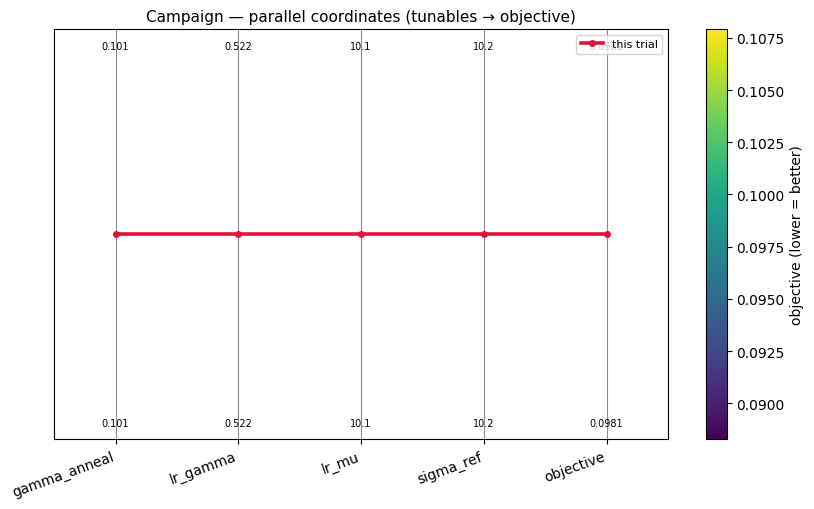

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 01 was the campaign anchor (sigma_ref 10.25, lr_mu 10.09, lr_gamma 0.52, gamma_anneal 0.10), close to the validated defaults. It ran in 6.5 min at the smoke budget (100x10 on the 8-experiment benchmark) and returned objective 0.0981 +/- 0.0194. The error is dominated by mu, which is underestimated in all eight experiments (-34% to -47%), giving rel RMSE 39.8% and a bias of -22.8 photons; the worst relative errors are the two Trans05 points (-46.4%, -46.9%), and the largest absolute misses are at high transmission (1nW Trans100 -34%, 3nW Trans100 -39%). gamma recovery is comparatively much better (rel RMSE 19.5%, bias -0.08): the one clear outlier is 3nW Trans05 at -41.4% (least signal, gamma_true 14.1 MHz), while the 1nW line is over-estimated by +13% to +22%. Per-experiment NLL spans 1.45 (1nW Trans05) to 6.21 (1nW Trans60), so the low-count fits are not obviously the worst. With no history yet, this trial is the baseline; the per-experiment pattern (mu systematically low everywhere) is what later trials will be compared against.

**Summary:** Trial 01 anchored near the defaults scored 0.0981 +/- 0.0194, with mu systematically underestimated in every experiment (-34% to -47%).
**Key insight:** The objective is mu-limited (rel RMSE 39.8% vs gamma 19.5%), and the mu bias is a uniform low shift rather than a few bad experiments.

[Notes for Anuar: this campaign is running under the smoke budget fixed in ag_hypopt.py (n_runs=100, n_iter=10); absolute objectives will shift once the budget is restored to 100x100, so only relative rankings across trials are meaningful right now.]

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 01 (sigma_ref 10.25, lr_mu 10.09, lr_gamma 0.52, gamma_anneal 0.10) scored 0.0981 +/- 0.0194, with mu systematically underestimated in every experiment (-34% to -47%).'
KEY_INSIGHT = 'The objective is mu-limited (rel RMSE 39.8% vs gamma 19.5%), and the mu bias is a uniform low shift rather than a few bad experiments.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_01 | current best: trial_01


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_02.ipynb. Open it and follow its cells from the top.
